# STEP 1 : import libraries

In [2]:
import pandas as pd

# STEP 2 : LOAD DATA

In [3]:
df=pd.read_csv('summer.csv')

# UNDERSTANDING DATA

#Basic Questions

1. How big is the data

In [4]:
df.shape
#data has : 31165 rows * 9 columns

(31165, 9)

2. what does data look like?

In [5]:
df.sample(5) 
#gives 5 random samples from data

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
28540,2008,Beijing,Hockey,Hockey,"BARRIONUEVO, Noel",ARG,Women,Hockey,Bronze
27912,2008,Beijing,Boxing,Boxing,"TISHCHENKO, Alexey",RUS,Men,57 - 60KG (Lightweight),Gold
1646,1908,London,Rowing,Rowing,"BLACKSTAFFE, Harry Thomas",GBR,Men,Single Sculls (1X),Gold
27609,2008,Beijing,Athletics,Athletics,"CALLENDER, Emmanuel",TRI,Men,4X100M Relay,Silver
3560,1920,Antwerp,Hockey,Hockey,"MCBRYAN, John Crawford",GBR,Men,Hockey,Gold


3. What are the data types of columns?

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31165 entries, 0 to 31164
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        31165 non-null  int64 
 1   City        31165 non-null  object
 2   Sport       31165 non-null  object
 3   Discipline  31165 non-null  object
 4   Athlete     31165 non-null  object
 5   Country     31161 non-null  object
 6   Gender      31165 non-null  object
 7   Event       31165 non-null  object
 8   Medal       31165 non-null  object
dtypes: int64(1), object(8)
memory usage: 2.1+ MB


4. Are there any missing values

In [7]:
df.isna().sum()
#4 records have missing countries 

Year          0
City          0
Sport         0
Discipline    0
Athlete       0
Country       4
Gender        0
Event         0
Medal         0
dtype: int64

5. How data looks like Mathematically

In [8]:
df.describe()

,Year
count,31165.000000
mean,1970.482785
std,33.158416
min,1896.000000
25%,1948.000000
50%,1980.000000
75%,2000.000000
max,2012.000000


6. Are there any duplicate values?

In [9]:
df.duplicated().sum()
#2 duplicate rows found

np.int64(2)

In [10]:
#If duplicate records exist 
#see duplicated rows : 
print(df[df.duplicated()])

#drop duplicate records
df.drop_duplicates()

       Year    City      Sport Discipline       Athlete Country Gender  \
16099  1980  Moscow     Hockey     Hockey  SINGH, Singh     IND    Men   
29785  2012  London  Badminton  Badminton  ZHAO, Yunlei     CHN  Women   

         Event Medal  
16099   Hockey  Gold  
29785  Doubles  Gold  


,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,100M Freestyle,Gold
1,1896,Athens,Aquatics,Swimming,"HERSCHMANN, Otto",AUT,Men,100M Freestyle,Silver
2,1896,Athens,Aquatics,Swimming,"DRIVAS, Dimitrios",GRE,Men,100M Freestyle For Sailors,Bronze
3,1896,Athens,Aquatics,Swimming,"MALOKINIS, Ioannis",GRE,Men,100M Freestyle For Sailors,Gold
4,1896,Athens,Aquatics,Swimming,"CHASAPIS, Spiridon",GRE,Men,100M Freestyle For Sailors,Silver
...,...,...,...,...,...,...,...,...,...
31160,2012,London,Wrestling,Wrestling Freestyle,"JANIKOWSKI, Damian",POL,Men,Wg 84 KG,Bronze
31161,2012,London,Wrestling,Wrestling Freestyle,"REZAEI, Ghasem Gholamreza",IRI,Men,Wg 96 KG,Gold
31162,2012,London,Wrestling,Wrestling Freestyle,"TOTROV, Rustam",RUS,Men,Wg 96 KG,Silver
31163,2012,London,Wrestling,Wrestling Freestyle,"ALEKSANYAN, Artur",ARM,Men,Wg 96 KG,Bronze


7. What is correclation between columns

In [11]:
df.corr(numeric_only=True)

,Year
Year,1.0


# EDA : UNIVARIATE ANALYSIS

# DATA VISUALISATION

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

COUNT PLOT and BAR CHART

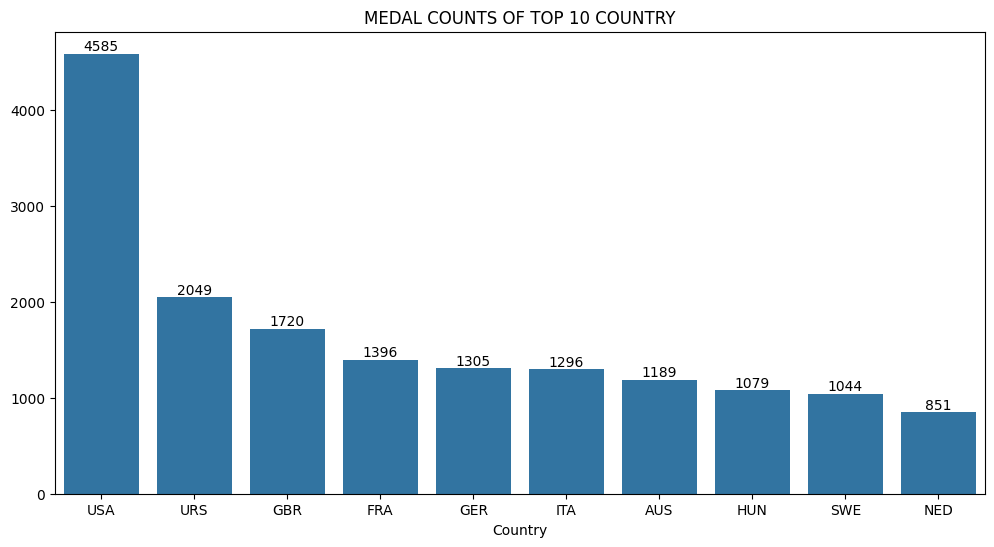

In [13]:
plt.figure(figsize=(12,6))
top_ten_country=df['Country'].value_counts().head(10)
ax=sns.barplot(x=top_ten_country.index,y=top_ten_country.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title('MEDAL COUNTS OF TOP 10 COUNTRY')
plt.show()

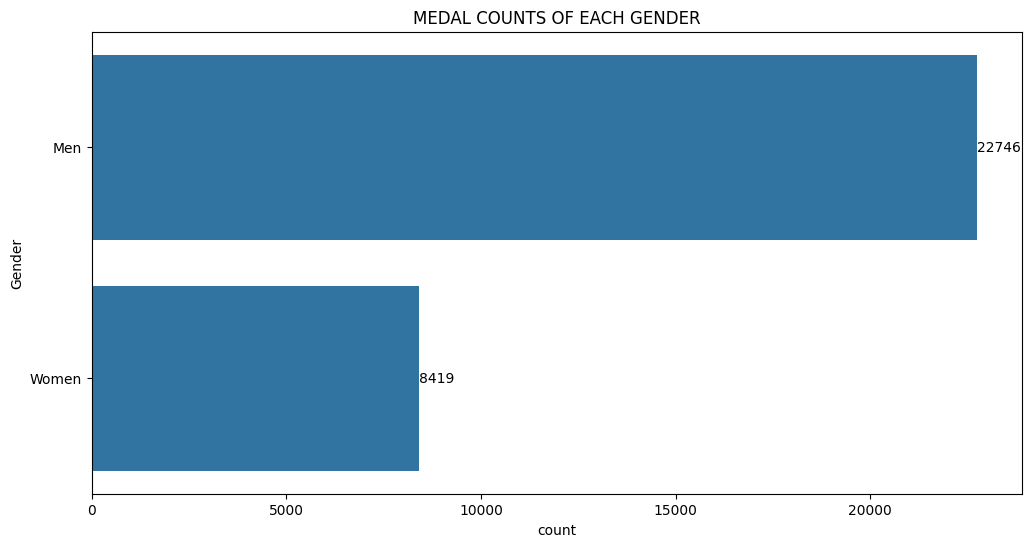

In [14]:
plt.figure(figsize=(12,6))
ax=sns.countplot(df['Gender'])

for container in ax.containers:
    ax.bar_label(container)

plt.title('MEDAL COUNTS OF EACH GENDER')
plt.show()

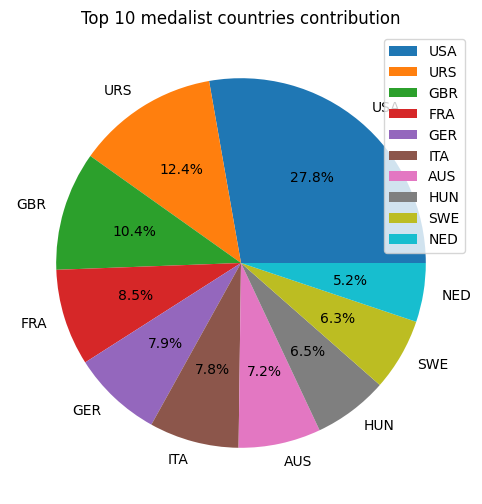

In [15]:
plt.figure(figsize=(12,6))
top_ten_country=df['Country'].value_counts().head(10)
plt.pie(top_ten_country.values,autopct='%1.1f%%',labels=top_ten_country.index)
plt.title('Top 10 medalist countries contribution')
plt.legend()
plt.show()

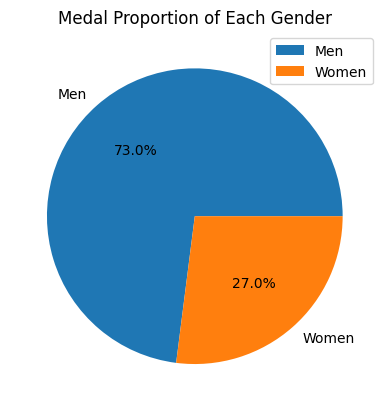

In [16]:
medal_by_gender=df['Gender'].value_counts()
plt.pie(medal_by_gender.values,autopct='%1.1f%%',labels=medal_by_gender.index)
plt.title('Medal Proportion of Each Gender')
plt.legend()
plt.show()

# BIVARIATE/MULTIVARIATE ANALYSIS

In [18]:
df.sample(5)

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
22721,1996,Atlanta,Rowing,Rowing,"VOLCHEK, Natalya",BLR,Women,Eight With Coxswain (8+),Bronze
27897,2008,Beijing,Boxing,Boxing,"LAFFITA HERNANDEZ, Andris",CUB,Men,48 - 51KG (Flyweight),Silver
20000,1992,Barcelona,Athletics,Athletics,"FORKEL, Karen",GER,Women,Javelin Throw,Bronze
10223,1960,Rome,Equestrian,Jumping,"OPPES, Antonio",ITA,Men,Team,Bronze
15919,1980,Moscow,Gymnastics,Artistic G.,"SHAPOSHNIKOVA, Natalia",URS,Women,Floor Exercises,Bronze


# How many countries participated in each Olympics?

LINE PLOT : used for TIME-BASED / TREND ANALYSIS

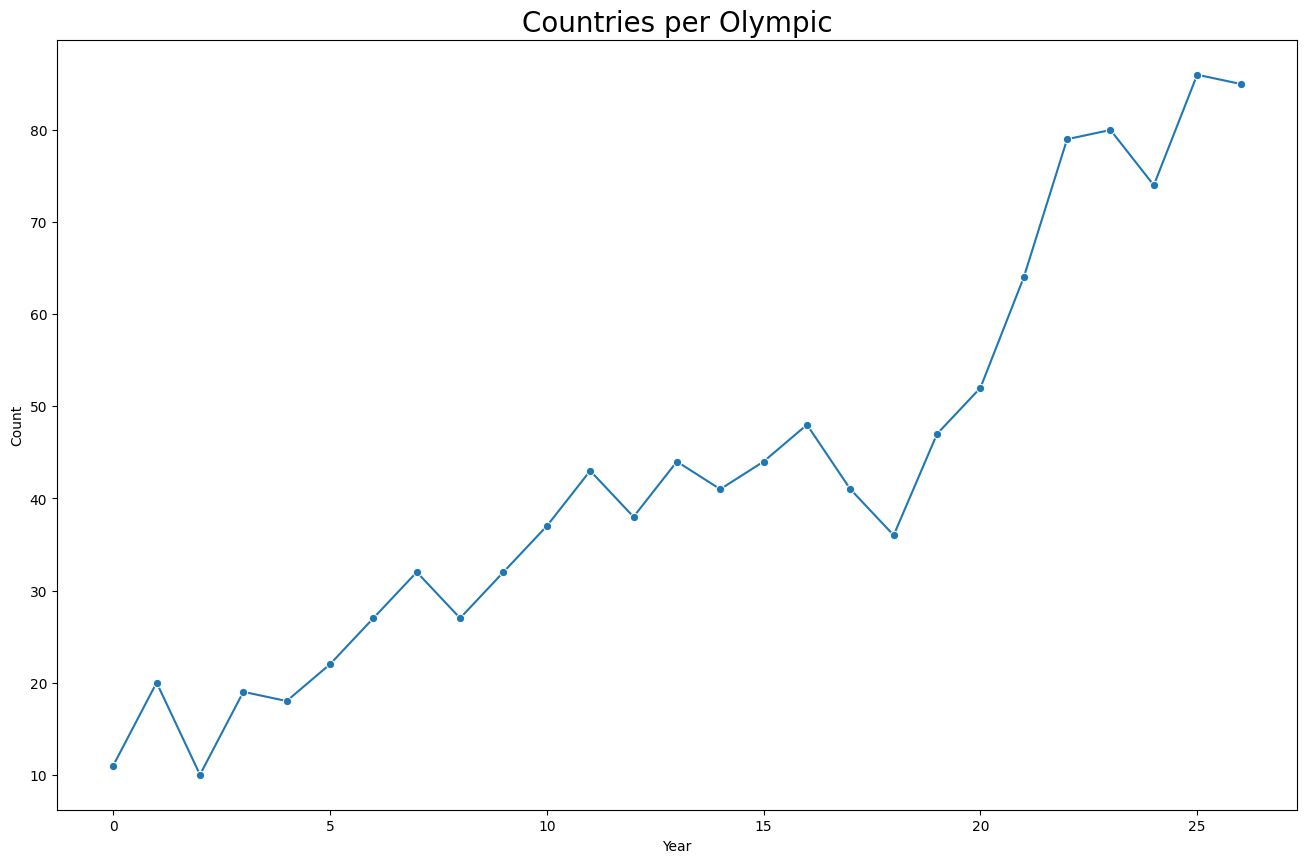

In [78]:
countries_per_olympic=df.groupby('Year')['Country'].nunique()
#print(countries_per_olympic)
plt.figure(figsize=(16,10))

sns.lineplot(countries_per_olympic.values,marker='o')
plt.title('Countries per Olympic',size=20)
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()
#this shows that participation of countries increases over the years

# How has the number of athletes changed over time?

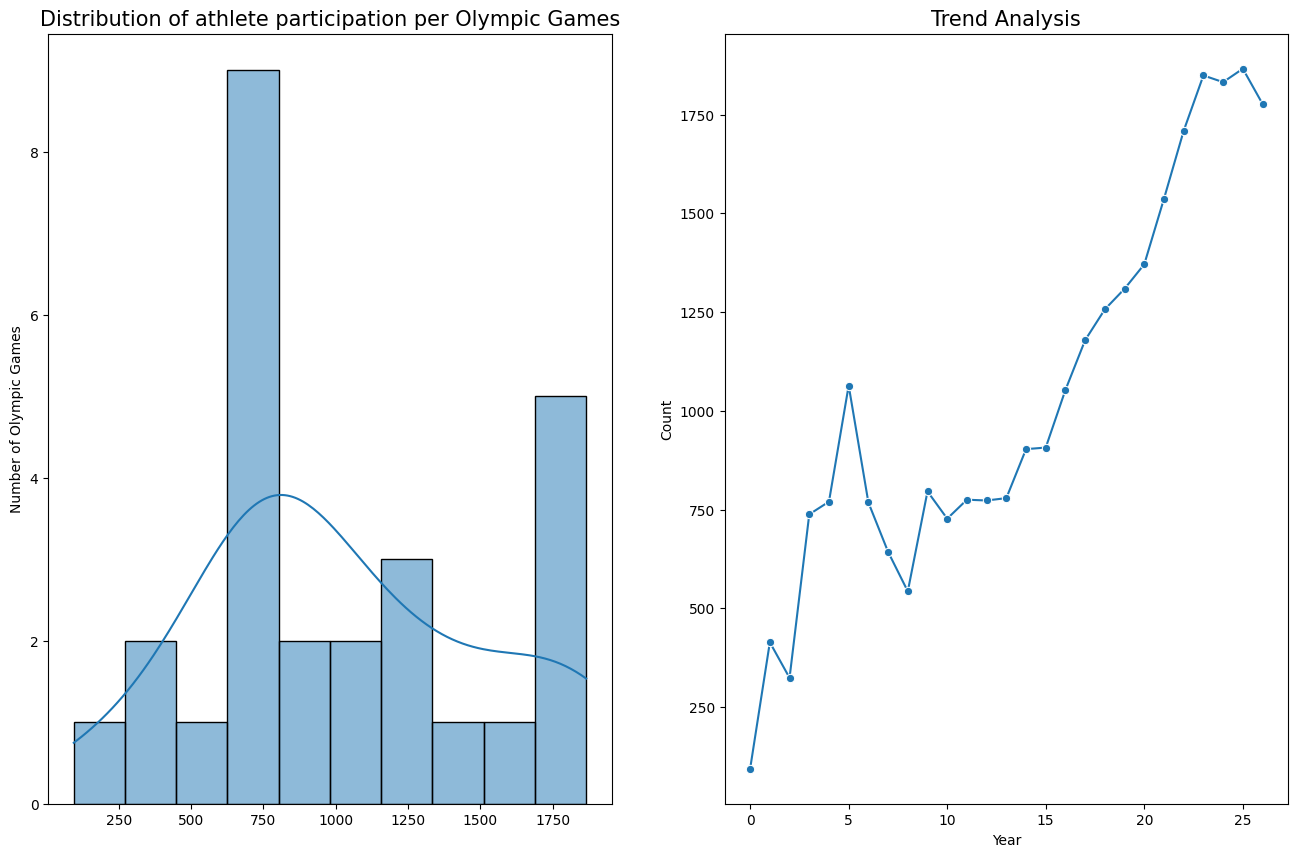

In [79]:
Athlete_participation_per_olympic=df.groupby('Year')['Athlete'].nunique()
fig,ax=plt.subplots(1,2,figsize=(16,10))
sns.histplot(Athlete_participation_per_olympic.values,bins=10,ax=ax[0],kde=True)
ax[0].set_title('Distribution of athlete participation per Olympic Games',size=15)
ax[0].set_ylabel('Number of Olympic Games')

sns.lineplot(Athlete_participation_per_olympic.values,ax=ax[1],marker='o')
ax[1].set_title('Trend Analysis',size=15)
ax[1].set_ylabel('Count')
ax[1].set_xlabel('Year')
plt.show()

# How many sports and events were added over the years?
nunique() - 

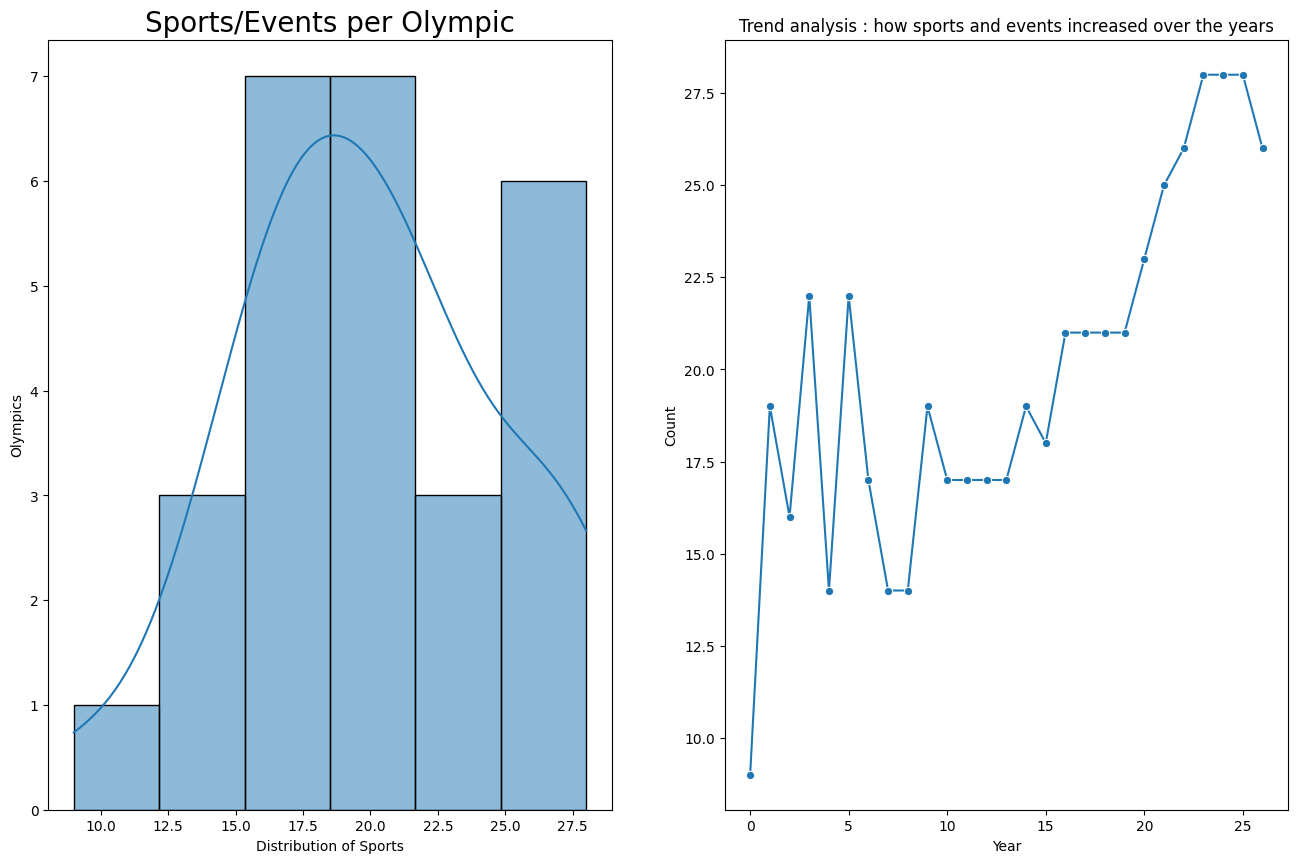

In [77]:
#EVENTS OVER THE YEARS
events_per_olympic=df.groupby('Year')['Sport'].nunique()
fig,ax=plt.subplots(1,2,figsize=(16,10))


sns.histplot(events_per_olympic.values,kde=True,ax=ax[0])
ax[0].set_title('Sports/Events per Olympic',size=20)
ax[0].set_xlabel('Distribution of Sports')
ax[0].set_ylabel('Olympics')
sns.lineplot(events_per_olympic.values,ax=ax[1],marker='o')
ax[1].set_title('Trend analysis : how sports and events increased over the years')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Count')
plt.show()

# Which cities hosted the Olympics most often?
Cities : categorical
Host Count : Numerical

In [ ]:
size() - Counts the number of rows in each group

Text(0.5, 0, 'Count')

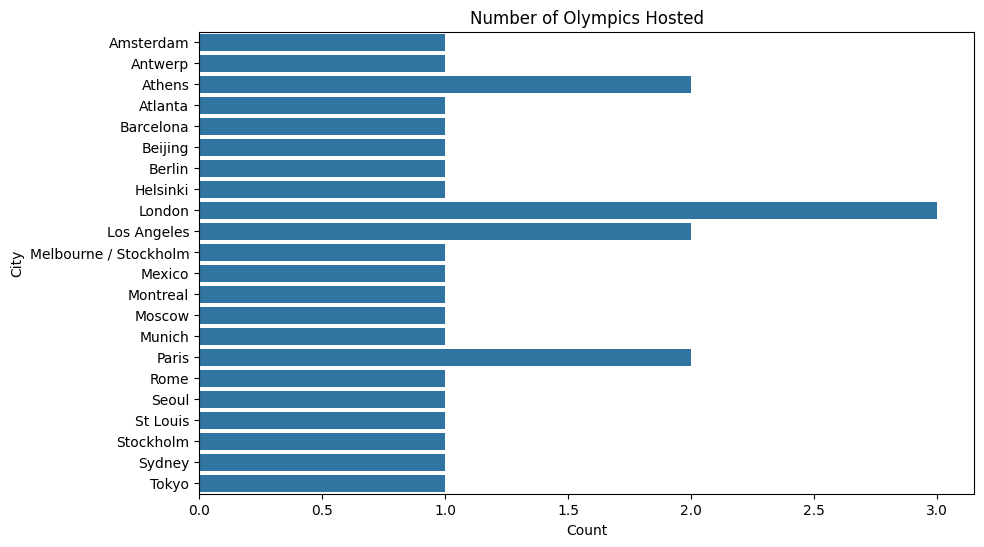

In [99]:
host_cities = df[['City','Year']].drop_duplicates().groupby('City').size()
plt.figure(figsize=(10,6))
sns.barplot(x=host_cities.values,y=host_cities.index)
plt.title('Number of Olympics Hosted')
plt.xlabel('Count')